# formocr — pipeline walkthrough

Scanned, handwritten QA form &rarr; structured JSON, one stage at a time, with the
intermediate image shown at every step.

This notebook **imports `src/formocr`** rather than reimplementing it, so it stays in
sync with the real pipeline — the modules are the source of truth, this is the lens.
Use it to see *why* a stage behaves the way it does, and to compare engines.

Runs locally or on Colab. On Colab it installs Tesseract, takes the package as a
one-time zip upload, and **prompts you to upload the PDF you want to look at**.

## 0. Environment

Installs whatever is missing. On Colab that includes the Tesseract binary itself
(`pytesseract` is only a wrapper) — the apt step takes a minute.

In [1]:
import importlib, subprocess, sys

IN_COLAB = "google.colab" in sys.modules


def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)


def ensure(module, *packages):
    try:
        importlib.import_module(module)
        return False
    except ImportError:
        pip(*(packages or (module,)))
        return True


if IN_COLAB:
    # opencv-headless: the GUI build pulls X11 libraries Colab has no use for.
    pip("pymupdf", "opencv-python-headless", "pytesseract", "pyyaml", "matplotlib")
    subprocess.run(["apt-get", "-qq", "install", "-y", "tesseract-ocr"], check=True)
else:
    ensure("cv2", "opencv-python")
    ensure("pymupdf")
    ensure("pytesseract")
    ensure("yaml", "pyyaml")
    ensure("matplotlib")

print("colab:", IN_COLAB)
print("python:", sys.version.split()[0])

colab: False
python: 3.13.7


## 1. Get the package

This notebook imports `src/formocr` instead of reimplementing it, so the package has to
reach the runtime once. Locally it is already there and this cell just finds it.

**On Colab** the cell prompts you to upload a zip — `src/` and `templates/` are the only
parts that matter, so a zip of just those two folders is enough and uploads in seconds.
It unpacks to `/content/OCR` and is then reused for the rest of the session.

Prefer Drive if you are iterating across sessions and would rather not re-upload:

```python
from google.colab import drive; drive.mount('/content/drive')
```

then run this cell again — `/content/drive/MyDrive/OCR` is one of the searched paths.

In [2]:
import sys, zipfile
from pathlib import Path


def find_project(roots):
    """A project root is any directory containing src/formocr."""
    for root in roots:
        if not root.exists():
            continue
        if (root / "src" / "formocr").is_dir():
            return root
        # A zip usually unpacks with its own top-level folder in the way.
        for nested in root.rglob("src/formocr"):
            return nested.parent.parent
    return None


SEARCH = [
    Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent,
    Path("/content/OCR"), Path("/content/drive/MyDrive/OCR"),
]

PROJECT = find_project(SEARCH)

if PROJECT is None and IN_COLAB:
    from google.colab import files

    print("Upload a zip of the project (src/ and templates/ are what matter):")
    uploaded = files.upload()
    archive = Path(next(iter(uploaded)))
    dest = Path("/content/OCR")
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(dest)
    PROJECT = find_project([dest])

if PROJECT is None:
    raise FileNotFoundError(
        "No src/formocr found. Upload a zip containing src/ and templates/, "
        "or mount Drive and re-run this cell."
    )

sys.path.insert(0, str(PROJECT / "src"))
from formocr import cells as cellmod
from formocr import grid as gridmod
from formocr import ingest, orient, pipeline
from formocr import template as tplmod
from formocr.cells import CellKind
from formocr.config import configure_tesseract

TEMPLATES_DIR = PROJECT / "templates"

print("project:  ", PROJECT)
print("tesseract:", configure_tesseract())
print("templates:", [t.form_id for t in tplmod.load_all(TEMPLATES_DIR)])

project:   E:\OCR
tesseract: C:\Program Files\Tesseract-OCR\tesseract.exe
templates: ['mis_plating', 'scrap_note']


## 2. Load a PDF

**On Colab this prompts you to upload one** — pick any scanned form; you can select
several and switch between them with `PDF = PDFS[n]` below. Uploads land in
`/content/pdfs` and survive for the session.

Locally it lists the PDFs already in the project instead.

Re-run just this cell to work on a different form; everything after it re-reads `PDF`.

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 110

PDF_DIR = Path("/content/pdfs") if IN_COLAB else PROJECT

if IN_COLAB:
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    existing = sorted(PDF_DIR.glob("*.pdf"))
    if existing:
        print(f"{len(existing)} PDF(s) already uploaded this session; "
              f"delete /content/pdfs to start over.\n")
    else:
        from google.colab import files

        print("Upload one or more scanned PDFs:")
        for name, blob in files.upload().items():
            (PDF_DIR / name).write_bytes(blob)

PDFS = sorted(p for p in PDF_DIR.rglob("*.pdf") if ".venv" not in str(p))
if not PDFS:
    raise FileNotFoundError("No PDFs available - re-run this cell and upload one.")

for i, p in enumerate(PDFS):
    print(f"  [{i}] {p.name}")

# Defaults to the form the README's measurements use so the walkthrough starts on a
# case that works, falling back to whatever was uploaded. Override freely:
# `PDF = PDFS[3]`. DAILY MIS REPORT PCOATING is the known-bad one (picks the wrong
# 90/270 orientation, has no template yet) - a poor first read, but the most useful
# thing here to point the notebook at.
PREFERRED = "SCRAP NOTE"
PDF = next((p for p in PDFS if PREFERRED in p.stem.upper()), PDFS[0])
print("\nselected:", PDF.name)


def show(img, title="", width=9):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    h, w = rgb.shape[:2]
    plt.figure(figsize=(width, width * h / w))
    plt.imshow(rgb, cmap=None if rgb.ndim == 3 else "gray")
    plt.title(title, fontsize=10)
    plt.axis("off")
    plt.show()


def show_row(images, titles, width=12):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(width, width / n))
    for ax, img, title in zip(np.atleast_1d(axes), images, titles):
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax.imshow(rgb, cmap=None if rgb.ndim == 3 else "gray")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

  [0] DAILY MIS REPORT PCOATING.pdf
  [1] MIS PLATING.pdf
  [2] PRESS SHOP REJECTION REPORT.pdf
  [3] SCRAP NOTE.pdf
  [4] ST. Pass weld data.pdf
  [5] SUPPLIER LOT REJECTION SUMMARY.pdf
  [6] SUPPLIER REJECTION REPORT.pdf
  [7] SUPPLIER REWORK REPORT.pdf
  [8] SUPPLIER SEGREGATION REPORT.pdf
  [9] WELD SHOP REJECTION REPORT.pdf

selected: SCRAP NOTE.pdf


## 3. Ingest — decide whether OCR is needed at all

A page carrying a real text layer is a digital PDF: the text is taken directly and no
OCR runs. Only scans continue down the pipeline.

For scans the embedded JPEG is extracted at **native resolution** rather than
re-rendered — these pages *are* a single full-page JPEG, and re-rendering would
resample it and soften exactly the handwriting strokes we need.

1 page(s)
  page 0: source=scan   (3506, 2481, 3)

native resolution: (3506, 2481, 3) -> 300 DPI at A4 width


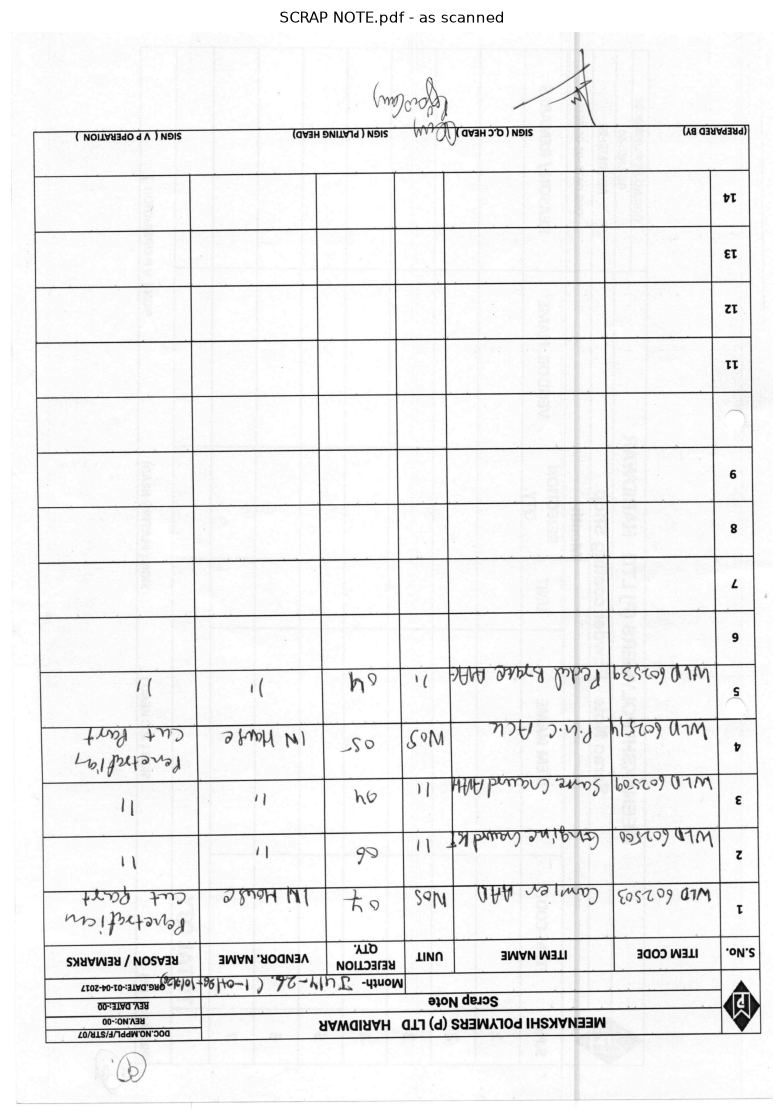

In [4]:
pages = ingest.load_pages(PDF)
print(f"{len(pages)} page(s)")
for pg in pages:
    detail = f"{pg.image.shape}" if pg.is_scan else f"{len(pg.text)} chars of text"
    print(f"  page {pg.index}: source={pg.source:5s}  {detail}")

page = next((p for p in pages if p.is_scan), None)
assert page is not None, "This PDF has a text layer on every page - no OCR needed."

raw = page.image
print("\nnative resolution:", raw.shape, "->", round(raw.shape[1] / 8.27), "DPI at A4 width")
show(raw, f"{PDF.name} - as scanned")

## 4. Perspective &rarr; rotation &rarr; skew

Three separate corrections, applied in this order for a reason.

`rectify` warps a *keystoned* page (a photo taken at an angle) flat. It finds the
table's four corners from its own ruling lines, then only warps if opposite sides
genuinely differ in length — a flatbed scan is already rectangular and passes through
untouched. It must run first because corner-finding is rotation-invariant but grid
detection is not: a slanted ruling line spreads its pixels across many columns and its
projection peak never clears the detection threshold.

`orient.normalize` then fixes 90&deg; steps via Tesseract OSD, and finally estimates
residual skew from the dominant horizontal ruling-line angle.

perspective corrected: False
rotation applied:      180 deg  (via osd)
skew applied:          -0.719 deg


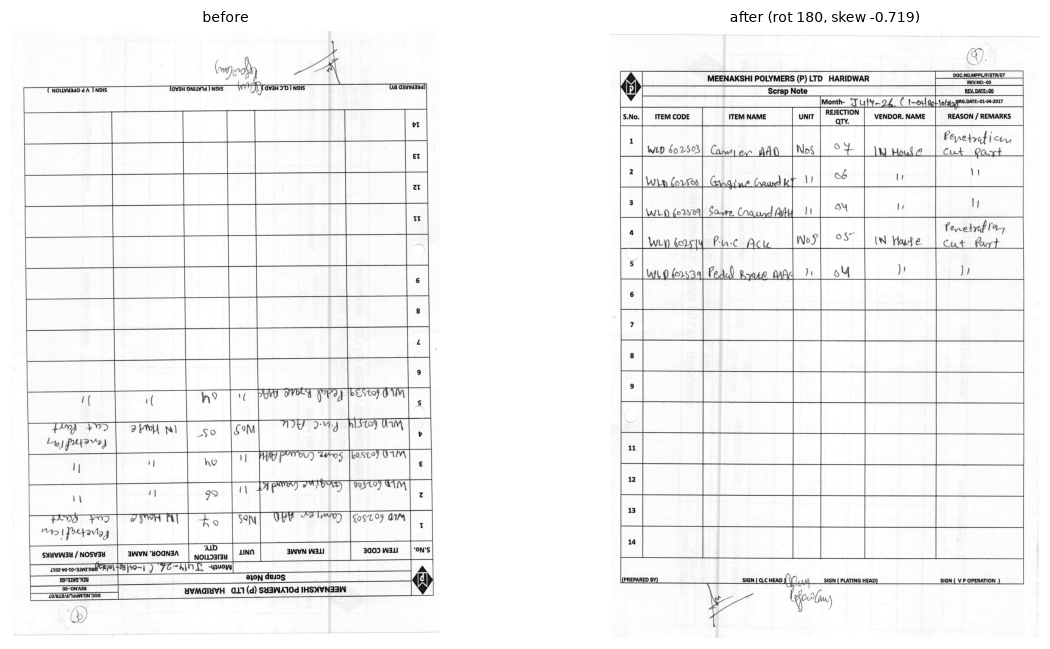

In [5]:
rectified, was_keystoned = gridmod.rectify(raw)
upright, orientation = orient.normalize(rectified)

print(f"perspective corrected: {was_keystoned}")
print(f"rotation applied:      {orientation.rotation} deg  (via {orientation.method})")
print(f"skew applied:          {orientation.skew} deg")

show_row([raw, upright], ["before", f"after (rot {orientation.rotation}, skew {orientation.skew})"])

## 5. Grid detection

The forms are pre-printed ruled tables, so the structure is physically drawn on the
page. **Directional morphological opening** recovers it: a `(width//40, 1)` kernel
erases everything that isn't a long horizontal stroke, `(1, height//40)` does the same
vertically. Handwriting and text vanish; only the lattice survives.

Each mask then collapses to a 1-D projection, thresholded at 30% of peak, with adjacent
runs grouped so one physical line yields one coordinate.

**Check the row/column pitch below.** A consistent pitch means the lattice is real. A
silently wrong grid produces well-formed, confident, completely misaligned JSON — this
is the failure mode that will not announce itself.

grid: 19 rows x 7 cols -> 133 cells

row pitch: [84, 58, 64, 108, 176, 177, 177, 178, 179, 177, 178, 179, 179, 178, 179, 180, 182, 181, 146]
col pitch: [126, 348, 520, 160, 255, 411, 506]


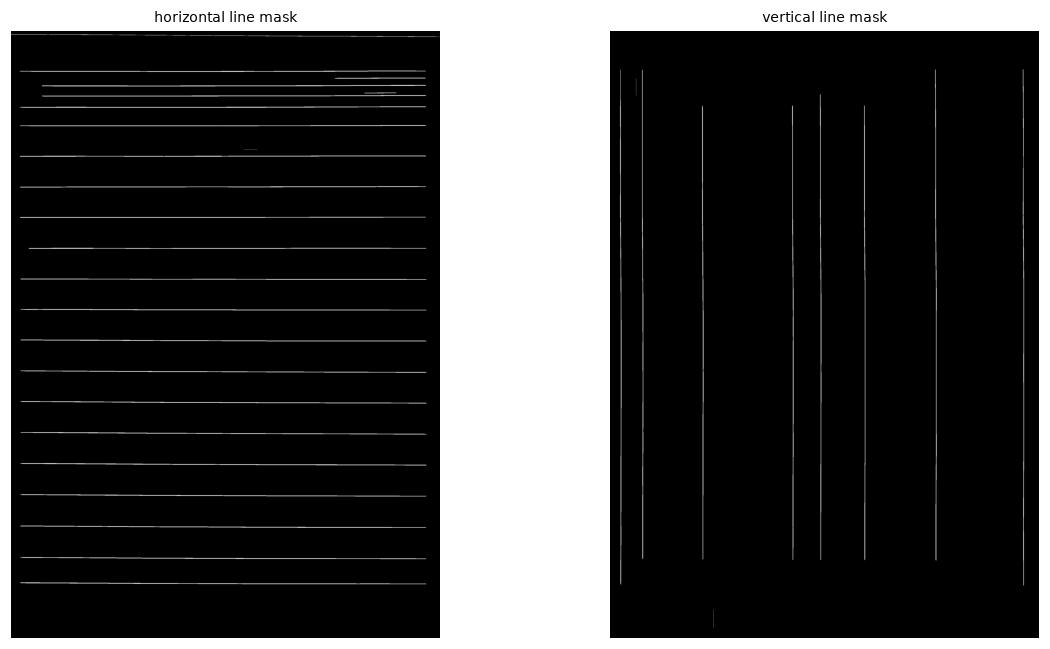

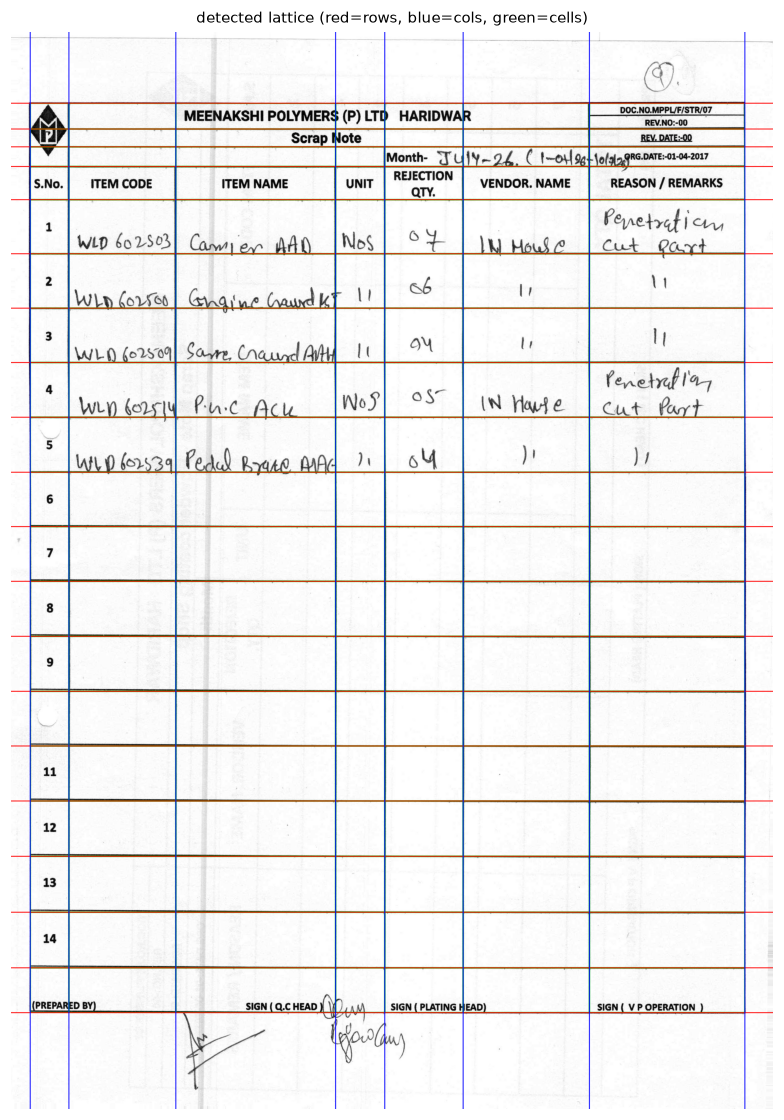

In [6]:
g = gridmod.detect(upright, relaxed_columns=was_keystoned)

print(f"grid: {g.n_rows} rows x {g.n_cols} cols -> {len(g.cells)} cells\n")
print("row pitch:", np.diff(g.ys).tolist())
print("col pitch:", np.diff(g.xs).tolist())

show_row([g.horizontal, g.vertical], ["horizontal line mask", "vertical line mask"])
show(gridmod.debug_overlay(upright, g), "detected lattice (red=rows, blue=cols, green=cells)")

## 6. Subtract the lattice

Two derived images, built once per page:

- **`ink`** — the ink mask with the grid removed, used to decide *whether a cell holds
  anything*.
- **`delined`** — greyscale with the ruling lines painted white, used for *what a cell
  says*.

This fixed two real bugs. Per-cell Otsu thresholding cannot tell blank paper from faint
ink — it always finds a split, so it manufactured ink in empty cells. And the ruling
lines wrecked Tesseract's page segmentation: the header read as `'(x) eee Ses SSS eee'`
and no template ever matched.

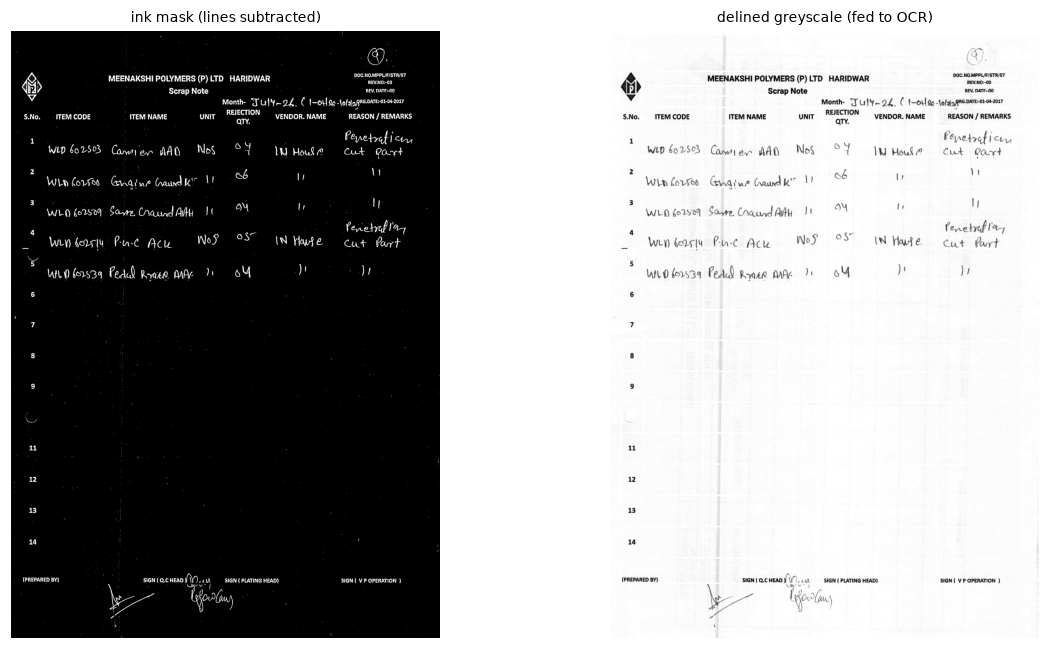

In [7]:
ink = gridmod.content_mask(upright, g)
delined = gridmod.remove_lines(upright, g)

show_row([ink, delined], ["ink mask (lines subtracted)", "delined greyscale (fed to OCR)"])

## 7. Identify the form

Only the top 18% of the page is OCR'd — enough to catch the printed title and document
number, and far more reliable than a full-page read. The matched template supplies the
column keys, types, and which rows are header vs data.

No match falls back to positional `col_0 … col_n` keys.

header text: & MEENAKSHI POLYMERS (P) LTD HARIDWAR ripened Hp Scrap Note REV. DATE:-00 bd Month- (Tuj¥-9Z. ( tor 94:-\ol9o,QR6-DATE:-01-04-2017 S.No. ITEM CODE ITEM NAME UNI 

matched form: scrap_note
header row: 3  first data row: 4
columns: [('s_no', 'integer', 'printed'), ('item_code', 'text', 'written'), ('item_name', 'text', 'written'), ('unit', 'text', 'written'), ('rejection_qty', 'integer', 'written'), ('vendor_name', 'text', 'written'), ('reason_remarks', 'text', 'written')]


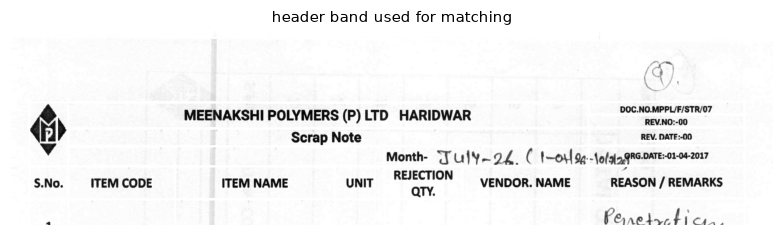

In [8]:
templates = tplmod.load_all(TEMPLATES_DIR)

from formocr.engines.tesseract_engine import TesseractEngine
tess = TesseractEngine()

band = delined[: int(delined.shape[0] * pipeline.HEADER_BAND_FRAC)]
header_text = " ".join(b.text for b in tess.read_page(band))
tpl = tplmod.match_template(header_text, templates) or tplmod.generic_template(g.n_cols)

print("header text:", header_text[:160], "\n")
print("matched form:", tpl.form_id)
print("header row:", tpl.header_row, " first data row:", tpl.first_data_row)
print("columns:", [(c.key, c.type, "printed" if c.printed else "written") for c in tpl.columns])

show(band, "header band used for matching")

## 8. Classify every cell *before* OCR

The largest single accuracy win in the pipeline, and it uses no model at all:

- ink ratio < 0.4% &rarr; **EMPTY**
- ink present but covering < 0.2% of area &rarr; **EMPTY** (speckle, bleed-through)
- one component, aspect &ge; 2.2, height &le; 35% of the cell &rarr; **DASH** = zero
- otherwise &rarr; **CONTENT**, and only this reaches a model

No engine ever gets the chance to hallucinate a digit into an empty box.

  content     72  (54%)
  empty       61  (46%)

61/133 cells (46%) resolved with no OCR at all


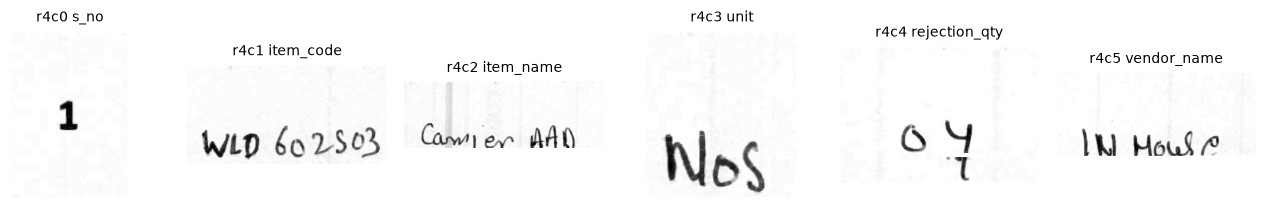

In [9]:
from collections import Counter

kinds, content_cells = {}, []
for cell in g.cells:
    kind = cellmod.classify(cell.crop(ink)).kind
    kinds[(cell.row, cell.col)] = kind
    if kind is CellKind.CONTENT:
        content_cells.append(cell)

counts = Counter(kinds.values())
total = len(g.cells)
skipped = counts[CellKind.EMPTY] + counts[CellKind.DASH]
for kind, n in counts.most_common():
    print(f"  {kind.value:8s} {n:5d}  ({n / total:.0%})")
print(f"\n{skipped}/{total} cells ({skipped / total:.0%}) resolved with no OCR at all")

preview = [c for c in content_cells if c.row >= tpl.first_data_row][:6]
if preview:
    show_row([c.crop(delined) for c in preview],
             [f"r{c.row}c{c.col} {tpl.column(c.col).key if tpl.column(c.col) else ''}"
              for c in preview])

## 9. Tesseract

Strong on the printed parts of these forms, weak on the handwriting — that is what it
is here for. It reads the structure, supplies OSD, and sets a measurable floor.

PSM 6 (uniform block) rather than the more obvious PSM 7 (single line), because cells
are not reliably one line — a remarks cell wraps, and PSM 7 forces it onto one baseline
and garbles it. Numeric columns get `tessedit_char_whitelist`, which structurally
cannot return a letter.

In [10]:
import time


def read_cells(engine, cell_list, tpl):
    rows = []
    for cell in cell_list:
        column = tpl.column(cell.col)
        if column is None:
            continue
        t0 = time.time()
        reading = engine.read_cell(cell.crop(delined), numeric=column.numeric)
        rows.append({
            "row": cell.row, "col": cell.col, "key": column.key,
            "numeric": column.numeric, "text": reading.text,
            "conf": round(reading.confidence, 3), "secs": round(time.time() - t0, 2),
        })
    return rows


# Sample from the data rows, skipping the title/header band. Those top rows are
# printed text, which both engines read well - the handwritten cells below are where
# they actually differ, and the only place the comparison is informative.
data_cells = [c for c in content_cells if c.row >= tpl.first_data_row]
SAMPLE = data_cells[:14]        # keep it quick; raise once you trust it
print(f"{len(data_cells)} content cells in data rows; sampling {len(SAMPLE)}\n")

t0 = time.time()
tess_rows = read_cells(tess, SAMPLE, tpl)
print(f"{len(tess_rows)} cells in {time.time() - t0:.1f}s\n")

print(f"{'cell':>8} {'column':<16} {'text':<26} {'conf':>5}")
for r in tess_rows:
    print(f"{'r%dc%d' % (r['row'], r['col']):>8} {r['key']:<16} {r['text'][:25]:<26} {r['conf']:>5.2f}")

51 content cells in data rows; sampling 14



14 cells in 4.5s

    cell column           text                        conf
    r4c0 s_no             1                           0.96
    r4c1 item_code        WLD 602503                  0.70
    r4c2 item_name        Cawier Wan                  0.16
    r4c3 unit             Nos                         0.71
    r4c4 rejection_qty    6 1                         0.42
    r4c5 vendor_name      IW Hous 7                   0.56
    r4c6 reason_remarks   Feynetyaficn, Cut Part      0.48
    r5c0 s_no             2                           0.96
    r5c1 item_code        WIL Corse                   0.14
    r5c2 item_name        (Ana | ui father kK'        0.43
    r5c3 unit                                         0.00
    r5c4 rejection_qty                                0.00
    r5c5 vendor_name      ly                          0.43
    r5c6 reason_remarks   \1                          0.65


## 10. TrOCR

Recognition-only — handed an already-cropped line it transcribes it, but it has no
text-detection stage, so `read_page` delegates to Tesseract.

**Constrained decoding is the interesting part.** Tesseract gets a charset whitelist for
free; TrOCR is a seq2seq language model with no such switch, so the equivalent happens
at the logits. `_AllowedTokensProcessor` masks the decoder to digits, space and control
tokens on numeric columns — the model then *cannot* spell a letter into a numeric cell,
rather than emitting one and having it stripped afterwards.

First run downloads ~1.3GB. On CPU expect 1.5–3s per cell; a CUDA build is roughly
5–10&times; faster.

In [11]:
ensure("torch")
ensure("transformers", "transformers<5")   # 5.x cannot load TrOCR's tokenizer

import torch
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

from formocr.engines.trocr_engine import TrOCREngine

t0 = time.time()
tro = TrOCREngine()
print(f"loaded on {tro.device} in {time.time() - t0:.0f}s")

mask = tro._numeric_token_mask()
allowed = mask.nonzero().flatten().tolist()
print(f"\nnumeric constraint: {mask.sum().item()} / {mask.numel()} tokens allowed "
      f"({mask.sum().item() / mask.numel():.1%} of vocabulary)")
print("sample:", [tro.processor.tokenizer.convert_ids_to_tokens(i) for i in allowed[:14]])

E:\OCR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.14.0+cpu | cuda available: False


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


loaded on cpu in 6s

numeric constraint: 1698 / 50265 tokens allowed (3.4% of vocabulary)
sample: ['<s>', '<pad>', '</s>', 'Ġ1', 'Ġ2', '1', '000', 'Ġ3', 'Ġ10', '2', 'Ġ2017', 'Ġ5', 'Ġ2018', 'Ġ4']


In [12]:
t0 = time.time()
trocr_rows = read_cells(tro, SAMPLE, tpl)
print(f"{len(trocr_rows)} cells in {time.time() - t0:.1f}s")

14 cells in 38.7s


## 11. Compare the two

Side by side on identical crops. Fill in `TRUTH` for cells you can read by eye — that
is the only way to turn *confidence* into *accuracy*.

Confidence is what an engine reports about itself, and an engine can be confidently
wrong. The two engines also calibrate differently, so comparing their confidence
numbers directly means very little. Truth is the only common yardstick.

In [13]:
# Fill in what you can actually read in the crops above: {(row, col): "truth"}
TRUTH = {}

print(f"{'cell':>8} {'column':<15} {'truth':<14} {'tesseract':<20} {'conf':>5}"
      f"  {'trocr':<20} {'conf':>5}")
print("-" * 98)

hits = {"tesseract": 0, "trocr": 0, "n": 0}
for a, b in zip(tess_rows, trocr_rows):
    truth = TRUTH.get((a["row"], a["col"]), "")
    if truth:
        hits["n"] += 1
        hits["tesseract"] += a["text"].strip() == truth
        hits["trocr"] += b["text"].strip() == truth
    print(f"{'r%dc%d' % (a['row'], a['col']):>8} {a['key']:<15} {truth:<14} "
          f"{a['text'][:19]:<20} {a['conf']:>5.2f}  {b['text'][:19]:<20} {b['conf']:>5.2f}")

print(f"\nmean confidence   tesseract {np.mean([r['conf'] for r in tess_rows]):.3f}"
      f"   trocr {np.mean([r['conf'] for r in trocr_rows]):.3f}")
print(f"mean seconds/cell tesseract {np.mean([r['secs'] for r in tess_rows]):.2f}"
      f"   trocr {np.mean([r['secs'] for r in trocr_rows]):.2f}")

if hits["n"]:
    print(f"\nexact match on {hits['n']} labelled cells:"
          f"   tesseract {hits['tesseract']}/{hits['n']}"
          f"   trocr {hits['trocr']}/{hits['n']}")
else:
    print("\nNo TRUTH entries - the numbers above are self-reported confidence, not accuracy.")

    cell column          truth          tesseract             conf  trocr                 conf
--------------------------------------------------------------------------------------------------
    r4c0 s_no                           1                     0.96  1                     0.93
    r4c1 item_code                      WLD 602503            0.70  who 602303            0.64
    r4c2 item_name                      Cawier Wan            0.16  Commission . SAN      0.35
    r4c3 unit                           Nos                   0.71  nos .                 0.74
    r4c4 rejection_qty                  6 1                   0.42  0 04                  0.74
    r4c5 vendor_name                    IW Hous 7             0.56  Initi House .         0.67
    r4c6 reason_remarks                 Feynetyaficn, Cut P   0.48  Perpetration .        0.73
    r5c0 s_no                           2                     0.96  2 2                   0.97
    r5c1 item_code                      WIL Co

## 12. The whole pipeline, both engines

Everything above in one call, producing the real JSON. `rows` is the data, `_meta`
records how the page was processed, and `review_queue` lists every value below 0.60
confidence with the bbox needed to crop it for correction.

Read `rows` for data, but treat anything in `review_queue` as unverified — a wrong read
lands there as a plausible-looking value, not as an error.

In [14]:
import json

results = {}
for name, engine in [("tesseract", tess), ("trocr", tro)]:
    t0 = time.time()
    results[name] = pipeline.process_pdf(PDF, engine, templates)
    print(f"{name:10s} {time.time() - t0:6.1f}s")

print()
for name, result in results.items():
    pg = result["pages"][0]
    m = pg["_meta"]
    print(f"{name:10s} {len(pg['rows'])} rows  "
          f"conf {m['mean_ocr_confidence']}  review {len(pg['review_queue'])}  "
          f"empty+dash {m['cells_empty'] + m['cells_dash']}/{m['cells_total']}")

tesseract    22.0s


trocr       124.0s

tesseract  5 rows  conf 0.477  review 22  empty+dash 54/133
trocr      5 rows  conf 0.579  review 23  empty+dash 54/133


In [15]:
page0 = results["trocr"]["pages"][0]

print("=== _meta ===")
print(json.dumps({k: v for k, v in page0["_meta"].items() if k != "matched_header_text"},
                 indent=2))

print("\n=== first row ===")
print(json.dumps(page0["rows"][0], indent=2, ensure_ascii=False))

print("\n=== first review_queue entry ===")
if page0["review_queue"]:
    print(json.dumps(page0["review_queue"][0], indent=2, ensure_ascii=False))

=== _meta ===
{
  "perspective_corrected": false,
  "orientation_applied": 180,
  "orientation_method": "osd",
  "skew_deg": -0.719,
  "grid_rows": 19,
  "grid_cols": 7,
  "cells_total": 133,
  "cells_empty": 54,
  "cells_dash": 0,
  "cells_ocr": 44,
  "cells_low_confidence": 23,
  "mean_ocr_confidence": 0.579,
  "checks_passed": 0,
  "checks_failed": 0,
  "engine": "trocr",
  "seconds": 124.0
}

=== first row ===
{
  "_row": 4,
  "s_no": 1,
  "item_code": "who 602303",
  "item_name": "Commission . SAN",
  "unit": "nos .",
  "rejection_qty": 4,
  "vendor_name": "Initi House .",
  "reason_remarks": "Perpetration .",
  "_confidence": 0.63
}

=== first review_queue entry ===
{
  "row": 4,
  "column": "item_name",
  "value": "Commission . SAN",
  "raw_text": "Commission . SAN",
  "confidence": 0.348,
  "bbox": [
    536,
    546,
    1056,
    722
  ]
}


## 13. Inspect the review queue visually

The point of `bbox`: crop the exact cell and put it next to what the engine said. This
is also how you build the fine-tuning set — each correction is a labelled pair, and
stock `trocr-base-handwritten` was trained on IAM (English cursive prose), not on
factory shorthand and part codes.

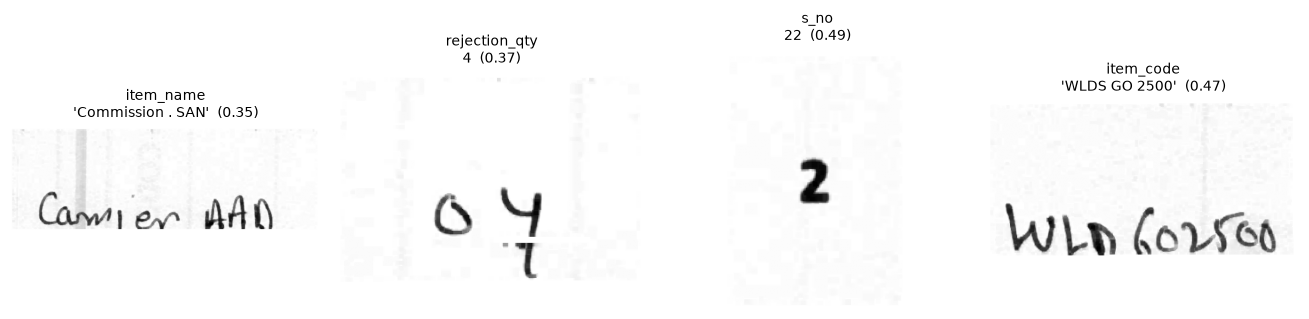

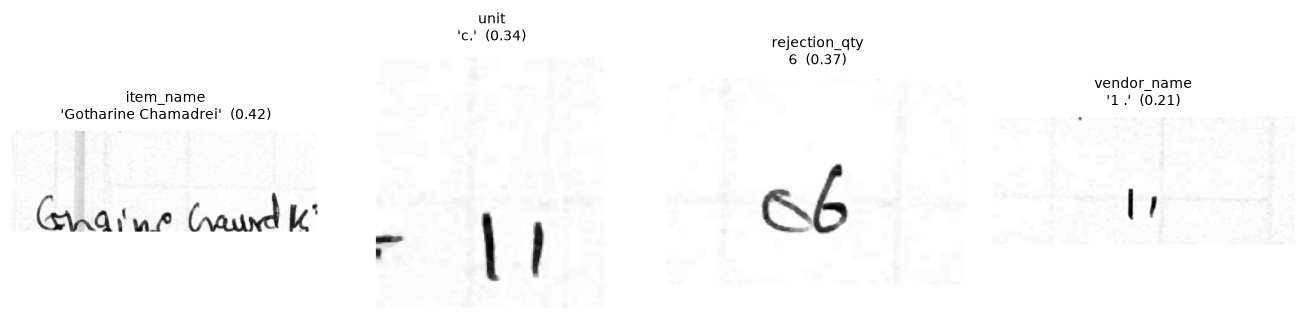

In [16]:
queue = page0["review_queue"][:8]
if queue:
    crops = [delined[e["bbox"][1]:e["bbox"][3], e["bbox"][0]:e["bbox"][2]] for e in queue]
    titles = [f"{e['column']}\n{e['value']!r}  ({e['confidence']:.2f})" for e in queue]
    for i in range(0, len(crops), 4):
        show_row(crops[i:i + 4], titles[i:i + 4])
else:
    print("Review queue is empty.")